$$\frac{\partial^2 u}{\partial t^2} = \frac{\partial^2 u}{\partial x^2} \quad ; -1 \le x \le 1$$

Initial Conditions
$$u(x, 0) = f(x) = \sin(\pi x),$$

$$u_t(x, 0) = g(x) = 0$$

with the boundary conditions

$$u(-1,t) = u(1,t) = 0.$$

The analytical solution is given in $[17]$ as

$$u(x,t) = \frac{1}{2}(\sin(\pi(x+t)) + \sin(\pi(x-t))).$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from SG_solver import rbf_matrix, second_divided_difference, d2_L_W2
from fractal_SG_solver_new import  build_fractal_second_derivative, d2_fractal_L_W2 

In [2]:
# Paper Example 1 parameters.
a = -1.0
b = 1.0
#######################
K = 10
s = 1
c = 0.027 
################
h = 0.1
tau = 0.01
################
T = 1
###################


$$x_i = a + \frac{i(b-a)}{n}, \quad i = 0, \ldots, n,$$

and $N = \frac{n}{K}$ , where K is a positive integer. The choice of
the interpolation centers $\{x_{k_j}\}_{j=1}^N$ as follows

$$x_{k_1} = x_1, \quad x_{k_N} = x_{n-1},$$

$$x_{k_j} = a + \frac{(j-1)(b-a)}{N}, \quad j = 2, \dots, N-1.$$

In [3]:
n = (b - a) / h

if n != int(n):
    raise ValueError("h must divide b-a exactly.")

n = int(n)

if n % K != 0:
    raise ValueError("n must be divisible by K because the paper defines N = n / K.")

N = n // K
# Nt = int(round(T / tau))
Nt = 0

x = np.linspace(a, b, n + 1)

# Interpolation center indices k_j, j = 1,...,N
k_idx = np.concatenate(([1], K * np.arange(1, N - 1), [n - 1])).astype(int)

xk = x[k_idx]
xkj = []
for j in range(1, N+1):
    if j == 1:
        value = float(x[1])
        xkj.append(value)

    elif 1 < j < N:
        value = a + ((j - 1) * (b - a)) / N
        xkj.append(value)
    elif j == N:
        value = float(x[n - 1])
        xkj.append(value)


# print(x)
# print(xk)
# print(xkj)

The analytical solution is given in $[17]$ as

$$u(x,t) = \frac{1}{2}(\sin(\pi(x+t)) + \sin(\pi(x-t))).$$

In [4]:
def exact_u(x, t):
    return 0.5 * (np.sin(np.pi * (x + t)) + np.sin(np.pi * (x - t)))
    # equivalently: np.sin(np.pi * x) * np.cos(np.pi * t)

At $t=0$, 
$$u(x,0) = \sin(\pi x).$$

In [5]:
# Storage for time and space levels
# U[d, i] ≈ u(x_i, d*tau), d=0,...,Nt

U = np.zeros((Nt + 2, len(x)))
print(np.shape(U))

# Initial condition at t=0
U[0, :] = exact_u(x, T)

(2, 21)


The boundary conditions

$$u(-1,t) = u(1,t) = 0.$$

In [6]:
U[0, 0]  = 0.0
U[0, -1] = 0.0

$$
\sum_{j=1}^{N} \alpha_j \varphi(|x_{k_i}-x_{k_j}|) =
\frac{2u_{k_i+1}^{n}}{(x_{k_i+1}-x_{k_i})(x_{k_i+1}-x_{k_i-1})}
+ \frac{2u_{k_i-1}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i-1})}
- \frac{2u_{k_i}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i})}.
\tag{19}$$

The right side is the same three-point second divided-difference formula from Eq. 15, and applied at the current time-level values $u_n$.
$$ \alpha_m = \sum_{i=1}^{N}\left[A^{-1}\right]_{mi}\left(\frac{2u_{k_i+1}^{n}}{(x_{k_i+1}-x_{k_i})(x_{k_i+1}-x_{k_i-1})} + \frac{2u_{k_i-1}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i-1})} - \frac{2u_{k_i}^{n}}{(x_{k_i}-x_{k_i-1})(x_{k_i+1}-x_{k_i})} \right),\\ \quad m=1,\ldots,N,$$
$$A_{ij}=\varphi(|x_{k_i}-x_{k_j}|)$$

In [7]:
# Build approximation of u_xx at t=0
A0 = rbf_matrix(xk, s)
rhs0 = []
for kj in k_idx:
    rhs0.append(second_divided_difference(x, U[0, :], kj))
rhs0 = np.asarray(rhs0)

alpha0 = np.linalg.solve(A0, rhs0)

# print("alpha0:", alpha0)

$$u_{k}^{n+1} = 2u_{k}^{n} - u_{k}^{n-1} + \tau^{2} \left[ \sum_{j=1}^{N} \alpha_{j} \varphi(x_{k} - x_{k_{j}}) + \sum_{i=0}^{n} \left( u_{i}^{n} - \sum_{j=1}^{N} \alpha_{j} \sqrt{s^{2} + (x_{i} - x_{k_{j}})^{2}} \right) \psi_{i}''(x_{k}) \right], \tag{18}$$
$$u_{k}^{n+1} = 2u_{k}^{n} - u_{k}^{n-1} + \tau^{2}*\left(L_{w_{2}}u_{k}^{n}\right)''$$

Given initial condition: 
$$u_t(x, 0) = g(x) = 0$$
Using Central Difference:
$$u_{k}^{-1}= u_{k}^{1}$$
We have
$$u_{k}^{1} = u_{k}^{0} + \frac{1}{2}*\tau^{2}*\left(L_{w_{2}}u_{k}^{n}\right)''$$


In [8]:
# for 1st time step
uxx0 = np.zeros(len(x))
for i in range(len(x)):
    uxx0[i] = d2_L_W2(i, x, U[0, :], xk, alpha0, s, c)
   
# Since g(x)=0
U[1, :] = U[0, :] + 0.5 * tau**2 * uxx0
U[1, 0]  = 0.0
U[1, -1] = 0.0

In [9]:
# Time stepping:
# u_k^{n+1} = 2u_k^n - u_k^{n-1} + tau^2 * (L_w2 u_k^d)''
# using d instead of n for time level index to avoid confusion with spatial index k.
count = 0
for d in range(1, Nt + 1):
    A = rbf_matrix(xk, s)
    rhs_d = np.asarray([second_divided_difference(x, U[d], kj) for kj in k_idx])
    alpha1 = np.linalg.solve(A, rhs_d)

    uxx = np.zeros(len(x))
    for i in range( len(x)):
        uxx[i] = d2_L_W2(i, x, U[d], xk, alpha1, s, c)

    U[d + 1, :] = 2.0 * U[d, :] - U[d - 1, :] + tau**2 * uxx

    # Dirichlet boundary conditions
    U[d + 1, 0] = 0.0
    U[d + 1, -1] = 0.0
    count += 1

In [10]:
# Fractal parameters
f_alpha = 0.01
n_points = 2000
n_iter = 100
n_subintervals = 5
f_x = np.linspace(a, b, n_subintervals)
fractal_dd = build_fractal_second_derivative(f_x, c, f_alpha, n_points, n_iter)

In [11]:
# Initial condition at t=0
f_U = np.zeros((Nt + 2, len(x)))
print(np.shape(f_U))
f_U[0, :] = exact_u(x, T)

f_U[0, 0]  = 0.0
f_U[0, -1] = 0.0

f_uxx0 = np.zeros(len(x))
for i in range(len(x)):
    # uxx0[i] = d2_L_W2(i, x, U[0, :], xk, alpha0, s, c)
    f_uxx0[i] = d2_fractal_L_W2(i, x, f_U[0, :], xk, alpha0, s, fractal_dd)

# Since g(x)=0
f_U[1, :] = f_U[0, :] + 0.5 * tau**2 * f_uxx0
f_U[1, 0]  = 0.0
f_U[1, -1] = 0.0

(2, 21)


In [12]:
# Time stepping:
# u_k^{n+1} = 2u_k^n - u_k^{n-1} + tau^2 * (L_w2 u_k^d)''
# using d instead of n for time level index to avoid confusion with spatial index k.
f_count = 0
for d in range(1, Nt + 1):
    A = rbf_matrix(xk, s)
    rhs_d = np.asarray([second_divided_difference(x, f_U[d], kj) for kj in k_idx])
    alpha2 = np.linalg.solve(A, rhs_d)

    f_uxx = np.zeros(len(x))
    for i in range( len(x)):
        f_uxx[i] = d2_fractal_L_W2(i, x, f_U[d], xk, alpha2, s, fractal_dd)

    f_U[d + 1, :] = 2.0 * f_U[d, :] - f_U[d - 1, :] + tau**2 * f_uxx

    # Dirichlet boundary conditions
    f_U[d + 1, 0] = 0.0
    f_U[d + 1, -1] = 0.0
    f_count += 1

In [13]:

# Final solution and error at time T

u_num = U[Nt + 1, :]
f_u_num = f_U[Nt + 1, :]
u_ex = exact_u(x, T )  # Exact solution at T+tau because of the central difference initialization)

err = -(u_ex - u_num)
f_err = -(u_ex - f_u_num)

abs_err = np.abs(err)
f_abs_err = np.abs(f_err)

Linf = np.max(abs_err)
f_Linf = np.max(f_abs_err)

RMS = np.sqrt(np.mean(abs_err**2))
f_RMS = np.sqrt(np.mean(f_abs_err**2))

Linf_difference = Linf - f_Linf
RMS_difference = RMS - f_RMS
# print(u_num)
print("Time steps =", count)
print("Fractal Time steps =", f_count)
print("n =", n)
print("N =", N)
print("Nt =", Nt)
print("Linf error =", Linf)
print("f_Linf error =", f_Linf)
print("RMS error  =", RMS)
print("f_RMS error  =", f_RMS)
print("Linf difference =", Linf_difference)
print("RMS difference =", RMS_difference)

Time steps = 0
Fractal Time steps = 0
n = 20
N = 2
Nt = 0
Linf error = 0.0008457043475070813
f_Linf error = 0.0008370141520140928
RMS error  = 0.0005721372486153124
f_RMS error  = 0.0005650932311207492
Linf difference = 8.69019549298855e-06
RMS difference = 7.044017494563194e-06


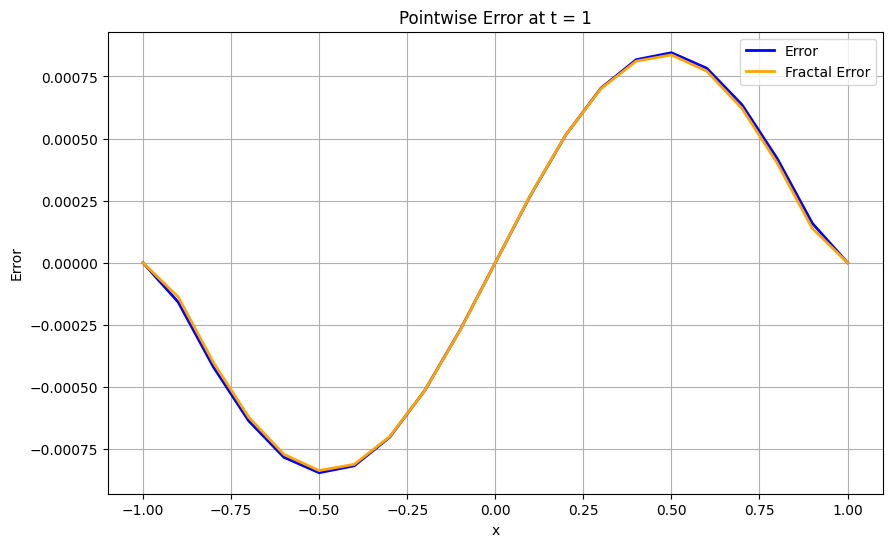

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(x, err, label="Error", color="blue", linewidth=2)
plt.plot(x, f_err, label="Fractal Error", color="orange", linewidth=2)
plt.xlabel("x")
plt.ylabel("Error")
plt.title(f"Pointwise Error at t = {T}")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
# import itertools
# import numpy as np
# import wandb

In [16]:
# wandb.login(key="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")


In [17]:
# Replace with your true values.
# f_alpha_by_n_subinterval = {
#     4: _parse_choices("-0.05, -0.04, -0.03, -0.02, -0.01, 0.01, 0.02, 0.03, 0.04, 0.05"),
#     5: _parse_choices("-0.035, -0.025, -0.015, -0.01, 0.01, 0.015, 0.025, 0.035"),
#     6: _parse_choices("-0.025, -0.02, -0.015, -0.01, 0.01, 0.015, 0.02, 0.025"),
#     7: _parse_choices("-0.0175, -0.015, -0.0125, -0.01, 0.01, 0.0125, 0.015, 0.0175"),
#     8: _parse_choices("-0.014, -0.010, -0.006, -0.002, 0.002, 0.006, 0.010, 0.014"),
#     9: _parse_choices("-0.0120, -0.009, -0.006, -0.003, 0.003, 0.006, 0.009, 0.0120"),
#     10: _parse_choices("-0.0090, -0.007, -0.005, -0.003, 0.003, 0.005, 0.007, 0.0090"),
# }

# wandb_config_template = {
#     "c": "0.02, 0.025, 0.027, 0.03, 0.035, 0.04",
#     "h": "0.125, 0.1, 0.08, 0.05, 0.04",   
#     "s": "0.6, 0.7, 0.8, 0.9, 1.0",
#     "n_subinterval": "4,5,6,7,8,9,10",
#     "f_alpha_rule": "depends on n_subinterval",
#     "K_rule": "must divide n=(b-a)/h",
# }

In [18]:


# def _parse_choices(spec):
#     parsed = []
#     for raw_value in spec.split(","):
#         token = raw_value.strip()
#         if "/" in token:
#             numerator, denominator = token.split("/")
#             parsed.append(float(numerator) / float(denominator))
#         else:
#             parsed.append(float(token))
#     return parsed


# wandb_search_grid = {
#     "c": _parse_choices(wandb_config_template["c"]),
#     "h": _parse_choices(wandb_config_template["h"]),
#     "s": _parse_choices(wandb_config_template["s"]),
#     "n_subinterval": [int(value) for value in _parse_choices(wandb_config_template["n_subinterval"])],
# }


# f_alpha_by_n_subinterval = {
#     4: _parse_choices("-0.05, -0.04, -0.03, -0.02, -0.01, 0.01, 0.02, 0.03, 0.04, 0.05"),
#     5: _parse_choices("-0.035, -0.025, -0.015, -0.01, 0.01, 0.015, 0.025, 0.035"),
#     6: _parse_choices("-0.025, -0.02, -0.015, -0.01, 0.01, 0.015, 0.02, 0.025"),
#     7: _parse_choices("-0.0175, -0.015, -0.0125, -0.01, 0.01, 0.0125, 0.015, 0.0175"),
#     8: _parse_choices("-0.014, -0.010, -0.006, -0.002, 0.002, 0.006, 0.010, 0.014"),
#     9: _parse_choices("-0.0120, -0.009, -0.006, -0.003, 0.003, 0.006, 0.009, 0.0120"),
#     10: _parse_choices("-0.0090, -0.007, -0.005, -0.003, 0.003, 0.005, 0.007, 0.0090"),
# }



# n_points = 2000
# n_iter = 100


# def get_n_from_h(a, b, h):
#     n = int(round((b - a) / h))
#     if not np.isclose(n * h, b - a):
#         raise ValueError(f"h={h} does not divide b-a exactly.")
#     return n


# def get_valid_K_values(n, preferred_K=None):
#     if preferred_K is None:
#         return [k for k in range(1, n + 1) if n % k == 0]
#     return [k for k in preferred_K if n % k == 0]


# def _build_problem_state(a, b, h, tau, T, K, s):
#     n_local = int(round((b - a) / h))
#     if not np.isclose(n_local * h, b - a):
#         raise ValueError("h must divide b-a exactly.")
#     if n_local % K != 0:
#         raise ValueError(f"Invalid K={K}: n={n_local} is not divisible by K.")

#     N_local = n_local // K
#     x_local = np.linspace(a, b, n_local + 1)

#     k_idx_local = np.concatenate(
#         ([1], K * np.arange(1, N_local - 1), [n_local - 1])
#     ).astype(int)
#     xk_local = x_local[k_idx_local]

#     Nt_local = int(round(T / tau))
#     if not np.isclose(Nt_local * tau, T):
#         raise ValueError("tau must divide T exactly.")

#     U_local = np.zeros((Nt_local + 2, len(x_local)))
#     U_local[0, :] = exact_u(x_local, T)
#     U_local[0, 0] = 0.0
#     U_local[0, -1] = 0.0

#     A_local = rbf_matrix(xk_local, s)
#     rhs0_local = np.asarray(
#         [second_divided_difference(x_local, U_local[0, :], kj) for kj in k_idx_local]
#     )
#     alpha0_local = np.linalg.solve(A_local, rhs0_local)

#     return {
#         "A": A_local,
#         "Nt": Nt_local,
#         "U0": U_local,
#         "alpha0": alpha0_local,
#         "k_idx": k_idx_local,
#         "x": x_local,
#         "xk": xk_local,
#         "tau": tau,
#         "h": h,
#         "n": n_local,
#         "K": K,
#         "s": s,
#     }


# def _make_standard_operator(s, c):
#     def _operator(i, x_local, u_local, xk_local, alpha_local):
#         return d2_L_W2(i, x_local, u_local, xk_local, alpha_local, s, c)
#     return _operator


# def _make_fractal_operator(s, fractal_dd):
#     def _operator(i, x_local, u_local, xk_local, alpha_local):
#         return d2_fractal_L_W2(i, x_local, u_local, xk_local, alpha_local, s, fractal_dd)
#     return _operator


# def _solve_wave_equation(state, derivative_fn):
#     U_local = state["U0"].copy()
#     x_local = state["x"]
#     xk_local = state["xk"]
#     k_idx_local = state["k_idx"]
#     A_local = state["A"]
#     alpha0_local = state["alpha0"]
#     Nt_local = state["Nt"]
#     tau_local = state["tau"]

#     uxx0_local = np.asarray([
#         derivative_fn(i, x_local, U_local[0, :], xk_local, alpha0_local)
#         for i in range(len(x_local))
#     ])

#     U_local[1, :] = U_local[0, :] + 0.5 * tau_local**2 * uxx0_local
#     U_local[1, 0] = 0.0
#     U_local[1, -1] = 0.0

#     for d in range(1, Nt_local + 1):
#         rhs_d = np.asarray([
#             second_divided_difference(x_local, U_local[d, :], kj)
#             for kj in k_idx_local
#         ])
#         alpha_local = np.linalg.solve(A_local, rhs_d)

#         uxx_local = np.asarray([
#             derivative_fn(i, x_local, U_local[d, :], xk_local, alpha_local)
#             for i in range(len(x_local))
#         ])

#         U_local[d + 1, :] = (
#             2.0 * U_local[d, :] - U_local[d - 1, :] + tau_local**2 * uxx_local
#         )
#         U_local[d + 1, 0] = 0.0
#         U_local[d + 1, -1] = 0.0

#     return U_local


# def _evaluate_solution(U_local, x_local, T):
#     u_num = U_local[-1, :]
#     u_ex = exact_u(x_local, T)
#     err = u_num - u_ex
#     abs_err = np.abs(err)

#     return {
#         "u_num": u_num,
#         "u_ex": u_ex,
#         "err": err,
#         "Linf": float(np.max(abs_err)),
#         "RMS": float(np.sqrt(np.mean(abs_err**2))),
#     }


# def run_wandb_trial(c, h, s, f_alpha, n_subinterval, K):
#     n = get_n_from_h(a, b, h)

#     run = wandb.init(
#         entity="fractal_on_pde",
#         project="SG_fractal_optimization",
#         config={
#             "c": c,
#             "h": h,
#             "n": n,
#             "K": K,
#             "s": s,
#             "f_alpha": f_alpha,
#             "n_subinterval": n_subinterval,
#             "f_alpha_rule": "conditional on n_subinterval",
#             "K_rule": "must divide n=(b-a)/h",
#         },
#         reinit=True,
#     )

#     try:
#         state = _build_problem_state(a, b, h, tau, T, K, s)

#         standard_operator = _make_standard_operator(s, c)
#         standard_solution = _solve_wave_equation(state, standard_operator)
#         standard_metrics = _evaluate_solution(standard_solution, state["x"], T)

#         fractal_x = np.linspace(a, b, n_subinterval + 1)
#         fractal_dd = build_fractal_second_derivative(
#             fractal_x, c, f_alpha, n_points, n_iter
#         )

#         fractal_operator = _make_fractal_operator(s, fractal_dd)
#         fractal_solution = _solve_wave_equation(state, fractal_operator)
#         fractal_metrics = _evaluate_solution(fractal_solution, state["x"], T)

#         linf_difference = standard_metrics["Linf"] - fractal_metrics["Linf"]

#         wandb.log(
#             {
#                 "status": "success",
#                 "standard_Linf": standard_metrics["Linf"],
#                 "standard_RMS": standard_metrics["RMS"],
#                 "fractal_Linf": fractal_metrics["Linf"],
#                 "fractal_RMS": fractal_metrics["RMS"],
#                 "Linf_difference": linf_difference,
#                 "c": c,
#                 "h": h,
#                 "n": n,
#                 "K": K,
#                 "s": s,
#                 "f_alpha": f_alpha,
#                 "n_subinterval": n_subinterval,
#             }
#         )

#         return {
#             "status": "success",
#             "standard": standard_metrics,
#             "fractal": fractal_metrics,
#             "Linf_difference": linf_difference,
#         }

#     except Exception as e:
#         wandb.log(
#             {
#                 "status": "failed",
#                 "error_message": str(e),
#                 "c": c,
#                 "h": h,
#                 "n": n,
#                 "K": K,
#                 "s": s,
#                 "f_alpha": f_alpha,
#                 "n_subinterval": n_subinterval,
#             }
#         )
#         raise

#     finally:
#         run.finish()


# def run_wandb_grid_search(max_trials=None, preferred_K=None, verbose=True):
#     best_result = None
#     best_score = -np.inf
#     trial_count = 0
#     success_count = 0
#     failed_trials = []

#     for h in wandb_search_grid["h"]:
#         try:
#             n = get_n_from_h(a, b, h)
#         except Exception as e:
#             failed_trials.append(
#                 {
#                     "stage": "h_validation",
#                     "h": h,
#                     "error": str(e),
#                 }
#             )
#             if verbose:
#                 print(f"Skipping h={h}: {e}")
#             continue

#         valid_K_values = get_valid_K_values(n, preferred_K=preferred_K)

#         if not valid_K_values:
#             failed_trials.append(
#                 {
#                     "stage": "K_generation",
#                     "h": h,
#                     "n": n,
#                     "error": "No valid K values found.",
#                 }
#             )
#             if verbose:
#                 print(f"Skipping h={h}, n={n}: no valid K values.")
#             continue

#         if verbose:
#             print(f"h={h}, n={n}, valid_K={valid_K_values}")

#         for n_subinterval in wandb_search_grid["n_subinterval"]:
#             if n_subinterval not in f_alpha_by_n_subinterval:
#                 failed_trials.append(
#                     {
#                         "stage": "f_alpha_lookup",
#                         "h": h,
#                         "n": n,
#                         "n_subinterval": n_subinterval,
#                         "error": "No f_alpha choices defined.",
#                     }
#                 )
#                 if verbose:
#                     print(f"Skipping n_subinterval={n_subinterval}: no f_alpha choices.")
#                 continue

#             f_alpha_choices = f_alpha_by_n_subinterval[n_subinterval]

#             for c, s, f_alpha, K in itertools.product(
#                 wandb_search_grid["c"],
#                 wandb_search_grid["s"],
#                 f_alpha_choices,
#                 valid_K_values,
#             ):
#                 trial_count += 1

#                 try:
#                     result = run_wandb_trial(
#                         c=c,
#                         h=h,
#                         s=s,
#                         f_alpha=f_alpha,
#                         n_subinterval=n_subinterval,
#                         K=K,
#                     )
#                     success_count += 1

#                     score = result["Linf_difference"]
#                     if score > best_score:
#                         best_score = score
#                         best_result = {
#                             "trial": trial_count,
#                             "c": c,
#                             "h": h,
#                             "n": n,
#                             "K": K,
#                             "s": s,
#                             "f_alpha": f_alpha,
#                             "n_subinterval": n_subinterval,
#                             "score": score,
#                             "result": result,
#                         }

#                     if verbose:
#                         print(
#                             f"[SUCCESS] trial={trial_count} "
#                             f"(c={c}, h={h}, s={s}, f_alpha={f_alpha}, "
#                             f"n_subinterval={n_subinterval}, K={K}) "
#                             f"score={score}"
#                         )

#                 except Exception as e:
#                     failed_trials.append(
#                         {
#                             "trial": trial_count,
#                             "c": c,
#                             "h": h,
#                             "n": n,
#                             "K": K,
#                             "s": s,
#                             "f_alpha": f_alpha,
#                             "n_subinterval": n_subinterval,
#                             "error_type": type(e).__name__,
#                             "error": str(e),
#                         }
#                     )

#                     if verbose:
#                         print(
#                             f"[FAILED] trial={trial_count} "
#                             f"(c={c}, h={h}, s={s}, f_alpha={f_alpha}, "
#                             f"n_subinterval={n_subinterval}, K={K}) -> "
#                             f"{type(e).__name__}: {e}"
#                         )

#                 if max_trials is not None and trial_count >= max_trials:
#                     return {
#                         "best_result": best_result,
#                         "trial_count": trial_count,
#                         "success_count": success_count,
#                         "failure_count": len(failed_trials),
#                         "failed_trials": failed_trials,
#                     }

#     return {
#         "best_result": best_result,
#         "trial_count": trial_count,
#         "success_count": success_count,
#         "failure_count": len(failed_trials),
#         "failed_trials": failed_trials,
#     }


# # Example usage:
# # summary = run_wandb_grid_search(max_trials=20, preferred_K=[2, 4, 6, 8, 10])
# # print(summary["best_result"])
# # print("Failures:", summary["failure_count"])

In [19]:
# best_run = run_wandb_grid_search()
# print("Best run:", best_run)